In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

In [8]:
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
info = info[info["Cell_Type"].isin(["K562", "K562_Mix"])]
info = info[info["ActD"].isna()]
info = info[info["UMIs"] >= 5000]
print(info.shape)

(687, 48)


In [21]:
for base in ["gene", "transcript"]:
    outfile = "results/h5ad/K562.%s_based.h5ad" % base
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        #continue
    array = []
    for cell in info.index:
        if base == "gene":
            path = "../../../1_NanoNASCseq/results/5_expression/4_quant_genes/min_read_2_min_tc_2/%s/%s.tsv" % (cell.split(".")[0], cell)
        else:
            path = "../../../1_NanoNASCseq/results/5_expression/6_quant_isoforms/min_read_2_min_tc_2/%s/%s.tsv" % (cell.split(".")[0], cell)
        d = pd.read_csv(path, sep="\t", index_col=0)
        s = d["Total"]
        s.name = cell
        array.append(s)
    m = pd.concat(array, axis=1).fillna(0).T
    adata = sc.AnnData(m)
    print(adata.shape)
    adata.obs = info[["s4U", "Time"]].copy()
    adata.obs["s4U"] = adata.obs["s4U"].astype("str")
    adata.obs["Time"] = adata.obs["Time"].astype("str")
    adata.obs["Group"] = ["%suM,%sh" % (s4u, time) for s4u, time in adata.obs[["s4U", "Time"]].values]
    adata.write(outfile, compression="gzip")

results/h5ad/K562.gene_based.h5ad exists!
(687, 18606)
results/h5ad/K562.transcript_based.h5ad exists!
(687, 37377)


--------------------------------------------------------------------------------
Base: gene
n_top_genes: 500
Outfile: figures/umap_of_k562.top500.gene_based.pdf
adata shape: (687, 14198)


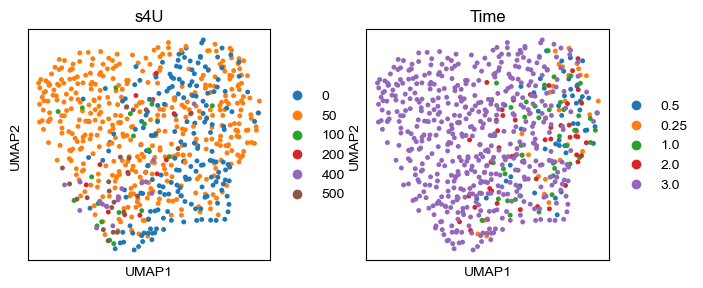

--------------------------------------------------------------------------------
Base: transcript
n_top_genes: 500
Outfile: figures/umap_of_k562.top500.transcript_based.pdf
adata shape: (625, 20054)


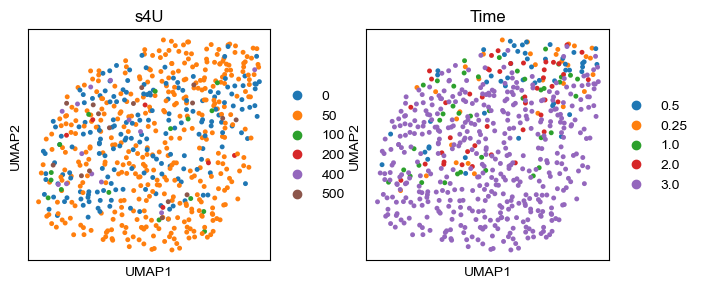

In [27]:
for base in ["gene", "transcript"]:
    # for n in [100, 200, 500, 800, 1000, 1500, 2000]:
    for n in [500]:
        print("-" * 80)
        print("Base:", base)
        print("n_top_genes:", n)

        infile = "results/h5ad/K562.%s_based.h5ad" % base
        outfile = "figures/umap_of_k562.top%d.%s_based.pdf" % (n, base)

        print("Outfile:", outfile)
        
        adata = sc.read_h5ad(infile)
        sc.pp.calculate_qc_metrics(adata, inplace=True, log1p=True)
        sc.pp.filter_cells(adata, min_genes=1000)
        sc.pp.filter_genes(adata, min_cells=3)
        
        print("adata shape:", adata.shape)
        
        adata.layers["counts"] = adata.X.copy()
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=n)
        # sc.pl.highly_variable_genes(adata)
        sc.tl.pca(adata)
        # sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
        # sc.pl.pca(adata)
        sc.pp.neighbors(adata, n_neighbors=15)
        sc.tl.umap(adata)
        with plt.rc_context({"figure.figsize": (3, 3)}):
            sc.pl.umap(adata, color=["s4U", "Time"], ncols=2, size=50, save="_tmp.pdf")
            ! mv figures/umap_tmp.pdf {outfile}